# Eval analysis

### imports

In [167]:
import logging
from dotenv import load_dotenv
from evals import Dataset
from evals.metrics import CollectMetrics
import warnings
from huggingface_hub.utils import _http
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from typing import Literal
import plotly.express as px
from plotly import subplots
import pandas as pd
from tqdm import tqdm
from pathlib import Path
import ast
from google.cloud import bigquery
logger = logging.getLogger(__name__)

logging.getLogger(__name__).setLevel(logging.DEBUG)
logging.getLogger("httpx").setLevel(logging.WARNING)
logging.getLogger("transformers").setLevel(logging.ERROR)
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)


warnings.filterwarnings(
    "ignore",
    message=".*UNEXPECTED.*",
    #message = ".*Warning.*",
    category=UserWarning,
    module="transformers.modeling_utils"  
)
save_figures = False
load_dotenv()

True

### Loading Data

In [168]:
def load_results(dataset_name):
    ds = Dataset(dataset_name)
    cm = CollectMetrics()
    eval_res = ds.load_evaluation_results()
    all_eval_runs = cm.organize_runs_by_type(eval_res)
    coll_res = ds.load_results()
    all_collected_res = cm.organize_runs_by_type(coll_res)
    #DeepEval
    logger.info("Collecting DeepEval metrics...")
    deepeval_obs = []
    for runs in tqdm(all_eval_runs.values()):
        deepeval_obs.extend(cm.collect_deepeval_metrics(runs))
    #bert metrics
    logger.info("Collecting BERT metrics...")
    berts = []
    for runs in tqdm(all_eval_runs.values()):
        berts.extend(cm.collect_berts(runs))
    #Resource metrics
    logger.info(f'Collecting resource metrics...')
    gathered_res = ds.load_results()
    resource_obs = cm.collect_resource_metrics(list(gathered_res.values()))

    logger.info("Merging metrics into DataFrame...")
    df_de = pd.DataFrame([dp.model_dump() for dp in deepeval_obs])
    df_brt = pd.DataFrame([bert.model_dump() for bert in berts])
    df_rm = pd.DataFrame([rm.model_dump() for rm in resource_obs])
    drop = [#"eval_run_id", 
            "name",
            #"query_id", "session_id", 
            ]
    on = ["llm_model", "dataset_name", 
            "query_id", "session_id", "agent_type",
            "session", "session_name"]

    df = pd.merge(df_de.drop(columns=drop, errors = "ignore"), df_rm.drop(columns=drop, errors = "ignore"), on = on,)
    
                                                                                                                
    df = pd.merge(df, df_brt.drop(columns=drop, errors = "ignore"), on = on)
    if "eval_run_id_x" in df.columns and "eval_run_id_y" in df.columns:
        df["eval_run_id"] = df["eval_run_id_x"].fillna(df["eval_run_id_y"])
    df.drop(columns=["eval_run_id_x", "eval_run_id_y"], inplace=True, errors="ignore")
    return df

In [169]:
client = bigquery.Client()
df = None
res = client.list_tables("staging")
for table in res:
    if table.table_id == "cached_results":
        logger.info("Cached results table already exists. Loading from BigQuery...")
        df = client.query("SELECT * FROM staging.cached_results").to_dataframe()
        break

if (hasattr(df, "empty") and df.empty) or df is None:
    logger.info("Cached results table not found. Loading from source and caching to BigQuery...")
    try:
        df_thrd = load_results("THRD-2021-163881")
    except Exception as e:
        print(f"Error loading THRD results: {e}")

    try:
        df_tosl = load_results("TOSL-2024-125319-MIN")
    except Exception as e:
        print(f"Error loading TOSL results: {e}")
    
    df = pd.concat([df_thrd, df_tosl], ignore_index=True)
    
    job = client.load_table_from_dataframe(df, "staging.cached_results", job_config=bigquery.LoadJobConfig(write_disposition="WRITE_TRUNCATE"))
    job.result()

INFO:__main__:Cached results table already exists. Loading from BigQuery...


In [170]:
df.head()

,dataset_name,query_id,session_id,session,session_name,llm_model,agent_type,question_type,correctness,relevancy,...,llm_calls,eval_run_id,bert_precision,bert_recall,bert_f1,s_bert_similarity,actual_output,expected_output,embedded_actual_output,embedded_expected_output
0,THRD-2021-163881,33e935c2-12d3-4f64-af96-134bc8392d4d,f76add1c-b783-4c83-8b0d-0148c565623f,3,Dom,google_gemini-2.5-flash,baseline_rag,analytical,0.7,1.0,...,1,71244c09-f195-497a-8a11-01d1a8235968,0.623730,0.675270,0.648478,0.875329,Saksøktes argumentasjon har utviklet seg og ti...,* Påberopte «solgt som den er» (§ 3-9) fra sta...,"[0.0013873809, 0.007878407, -0.0074765496, -0....","[-0.011398638, 0.016385054, -0.014769202, -0.0..."
1,THRD-2021-163881,33e935c2-12d3-4f64-af96-134bc8392d4d,6bfd63c5-889d-409d-9a8a-1cc3ed839737,3,Dom,google_gemini-2.5-flash,custom,analytical,0.8,1.0,...,1,2fe8a6bc-bfe7-437e-9965-4eeaa7bcd5e7,0.651441,0.684252,0.667443,0.911797,Saksøktes argumentasjon har utviklet seg gjenn...,* Påberopte «solgt som den er» (§ 3-9) fra sta...,"[-0.0056930636, 0.024024209, -0.010612537, -0....","[-0.011398638, 0.016385054, -0.014769202, -0.0..."
2,THRD-2021-163881,33e935c2-12d3-4f64-af96-134bc8392d4d,2c610e21-8357-47af-9427-7b14c3514e3a,3,Dom,google_gemini-2.5-flash,custom,analytical,0.7,1.0,...,1,31cc3243-4e27-44b2-801b-db2d06441d16,0.633632,0.676344,0.654292,0.909213,Saksøktes argumentasjon har utviklet seg gjenn...,* Påberopte «solgt som den er» (§ 3-9) fra sta...,"[-0.0048873895, 0.023550818, -0.005255725, -0....","[-0.011398638, 0.016385054, -0.014769202, -0.0..."
3,THRD-2021-163881,33e935c2-12d3-4f64-af96-134bc8392d4d,ea410d98-7747-40f7-a596-52054f468df1,3,Dom,google_gemini-2.5-pro,baseline_rag,analytical,1.0,1.0,...,1,34ba230d-7f66-4af4-8ccf-3637e902cb9d,0.622198,0.660789,0.640913,0.891115,Basert på dommen og saksforløpet har saksøktes...,* Påberopte «solgt som den er» (§ 3-9) fra sta...,"[0.0021760992, 0.01505906, -0.0130419, -0.0622...","[-0.011398638, 0.016385054, -0.014769202, -0.0..."
4,THRD-2021-163881,33e935c2-12d3-4f64-af96-134bc8392d4d,1685faaa-83c3-4ac4-a7d0-10d3b599b90a,3,Dom,google_gemini-2.5-pro,baseline_rag,analytical,1.0,1.0,...,1,7bec77b3-332b-4de4-88ff-01a1684dc370,0.626492,0.668081,0.646618,0.882954,Basert på dommen kan saksøktes argumentasjon b...,* Påberopte «solgt som den er» (§ 3-9) fra sta...,"[-0.010244023, 0.018687092, -0.01131389, -0.05...","[-0.011398638, 0.016385054, -0.014769202, -0.0..."


In [171]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 884 entries, 0 to 883
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   dataset_name              884 non-null    object        
 1   query_id                  884 non-null    object        
 2   session_id                884 non-null    object        
 3   session                   884 non-null    Int64         
 4   session_name              884 non-null    object        
 5   llm_model                 884 non-null    object        
 6   agent_type                884 non-null    object        
 7   question_type             884 non-null    object        
 8   correctness               884 non-null    float64       
 9   relevancy                 884 non-null    float64       
 10  completeness              542 non-null    float64       
 11  success                   884 non-null    boolean       
 12  starttime             

In [172]:
#rm to ensure balanced dataset
runs_to_remove = ["a92151b8-555e-4a51-9f2f-2f01564f5459", "2ae28c5d-6898-418d-ae88-501370d590cd","b70856d7-c340-47bb-8ff3-f717ffce0a1a", #THRD custom
                  "8d23b984-96bf-488f-bf4f-4fe47ddaa15d","71244c09-f195-497a-8a11-01d1a8235968","6f733336-3894-4e66-ba0f-de7b556a8833", #THRD baseline
                  "aaa8973a-723e-4399-80a0-97163b75068e","0557ba01-e084-49ed-802b-3a9d8bded76b",  #TOSL custom
                  "5eb75860-5461-4f66-af65-202174301caf", #"c25cd77b-aba3-436a-b1a8-7f5b6469a6b9",
                  ] #TOSL baseline
df = df[~df["eval_run_id"].isin(runs_to_remove)]

In [173]:
def standardize_model_names(df):
    df.loc[df["llm_model"] == "qwen_Qwen/Qwen3-Next-80B-A3B-Instruct" , "llm_model"] = "Qwen3-Next-80B-A3B-Instruct"
    df.loc[df["llm_model"] == "qwen_Qwen/Qwen3.5-397B-A17B" , "llm_model"] = "Qwen3.5-397B-A17B"
    df.loc[df["llm_model"] == "zai_zai-org/GLM-5" , "llm_model"] = "GLM-5"
    df.loc[df["llm_model"] == "google_gemini-2.5-flash" , "llm_model"] = "gemini-2.5-flash"
    df.loc[df["llm_model"] == "google_gemini-2.5-pro" , "llm_model"] = "gemini-2.5-pro"

    models_to_keep = ["Qwen3.5-397B-A17B", "GLM-5", "gemini-2.5-flash", "gemini-2.5-pro"]
    df = df[df["llm_model"].isin(models_to_keep)]
standardize_model_names(df)
df["llm_model"].value_counts()

llm_model
gemini-2.5-flash     186
gemini-2.5-pro       186
Qwen3.5-397B-A17B    186
GLM-5                185
Name: count, dtype: int64

''

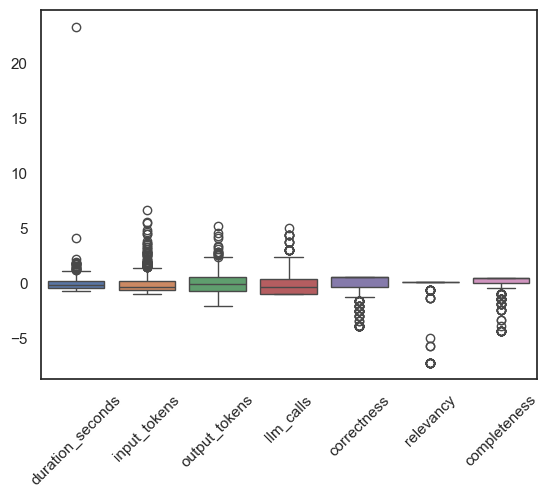

In [174]:
#check for anomalies
df_sel = df.loc[:,["duration_seconds", "input_tokens", "output_tokens", "llm_calls", "correctness", "relevancy", "completeness"]]
df_sel_norm = (df_sel - df_sel.mean()) / df_sel.std()
sns.boxplot(data=df_sel_norm)
plt.xticks(rotation=45)
;

In [175]:
df = df.loc[df["duration_seconds"] < 600, :].reset_index(drop=True) #remove runs longer than 10 minutes

In [176]:
df.loc[df["dataset_name"] == "TOSL-2024-125319-MIN", :].groupby(["llm_model", "agent_type"])["query_id"].count()

llm_model          agent_type  
GLM-5              baseline_rag    44
                   custom          45
Qwen3.5-397B-A17B  baseline_rag    45
                   custom          45
gemini-2.5-flash   baseline_rag    45
                   custom          45
gemini-2.5-pro     baseline_rag    45
                   custom          45
Name: query_id, dtype: int64

In [177]:
df.loc[df["dataset_name"] == "THRD-2021-163881", :].groupby(["llm_model", "agent_type"])["query_id"].count()

llm_model          agent_type  
GLM-5              baseline_rag    48
                   custom          47
Qwen3.5-397B-A17B  baseline_rag    48
                   custom          48
gemini-2.5-flash   baseline_rag    48
                   custom          48
gemini-2.5-pro     baseline_rag    48
                   custom          48
Name: query_id, dtype: int64

In [178]:
print(f'Unique queries: {df["query_id"].nunique()}')
print(f'Unique answers: {len(df)}')

Unique queries: 31
Unique answers: 742


## EDA

In [44]:
#Style settings
sns.set_palette("Set2")
palette = {"custom": "tab:orange", "baseline_rag": "tab:blue"}
agent_order = ["custom", "baseline_rag"]

### Deep Eval metrics
Correctness, Relevancy & Completeness

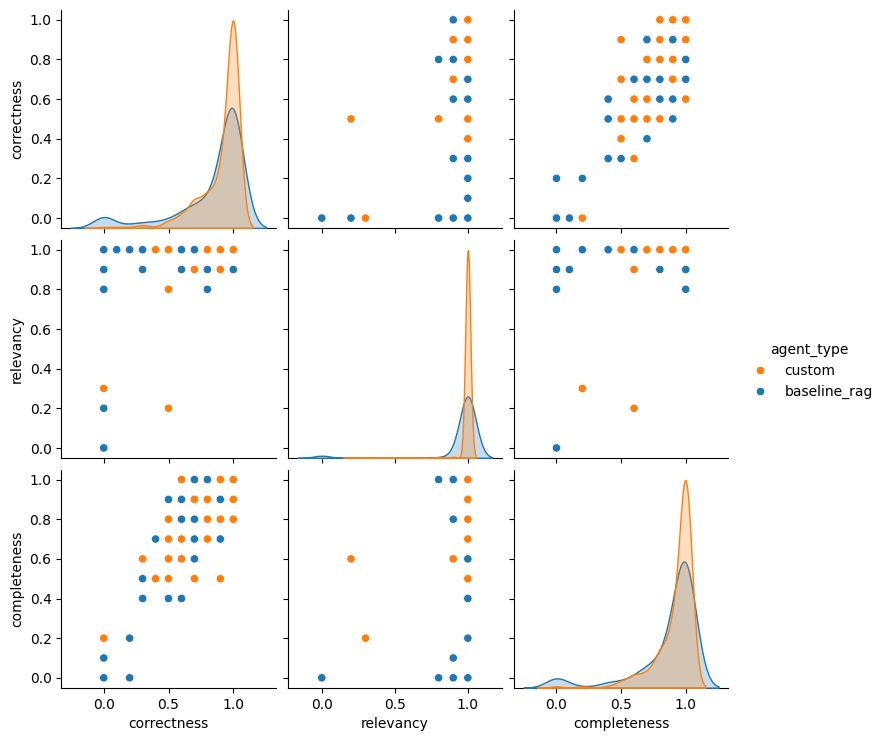

In [45]:
sns.pairplot(df[["correctness", "relevancy", "completeness", "llm_model", "agent_type"]], 
             hue_order=agent_order,
             palette=palette,
             hue = "agent_type")
plt.savefig(f'../thesis/figures/deep_eval_pairplot.png') if save_figures else None

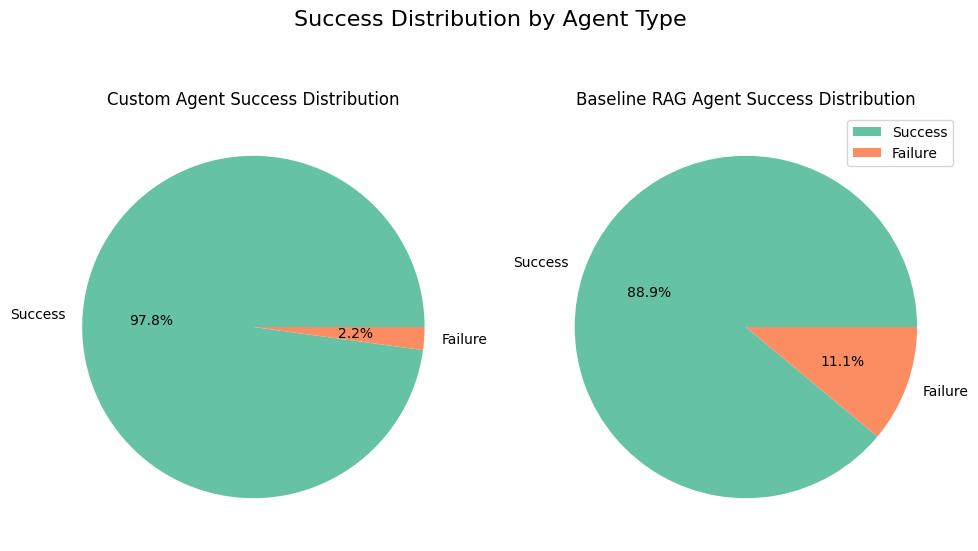

In [46]:
fig,ax = plt.subplots(figsize=(10,10),nrows = 1, ncols = 2)
ax[0].pie(df.loc[df["agent_type"] == "custom", "success"].value_counts(), 
          labels = ["Success", "Failure"], 
          autopct='%1.1f%%',
          )
ax[0].set_title("Custom Agent Success Distribution")
ax[1].pie(df.loc[df["agent_type"] == "baseline_rag", "success"].value_counts(), 
          labels = ["Success", "Failure"], 
          autopct='%1.1f%%')
ax[1].set_title("Baseline RAG Agent Success Distribution")

plt.suptitle("Success Distribution by Agent Type", y = 0.8, fontsize = 16,)
plt.legend()
plt.tight_layout()
plt.savefig(f'../thesis/figures/deep_eval_success_distribution.png') if save_figures else None

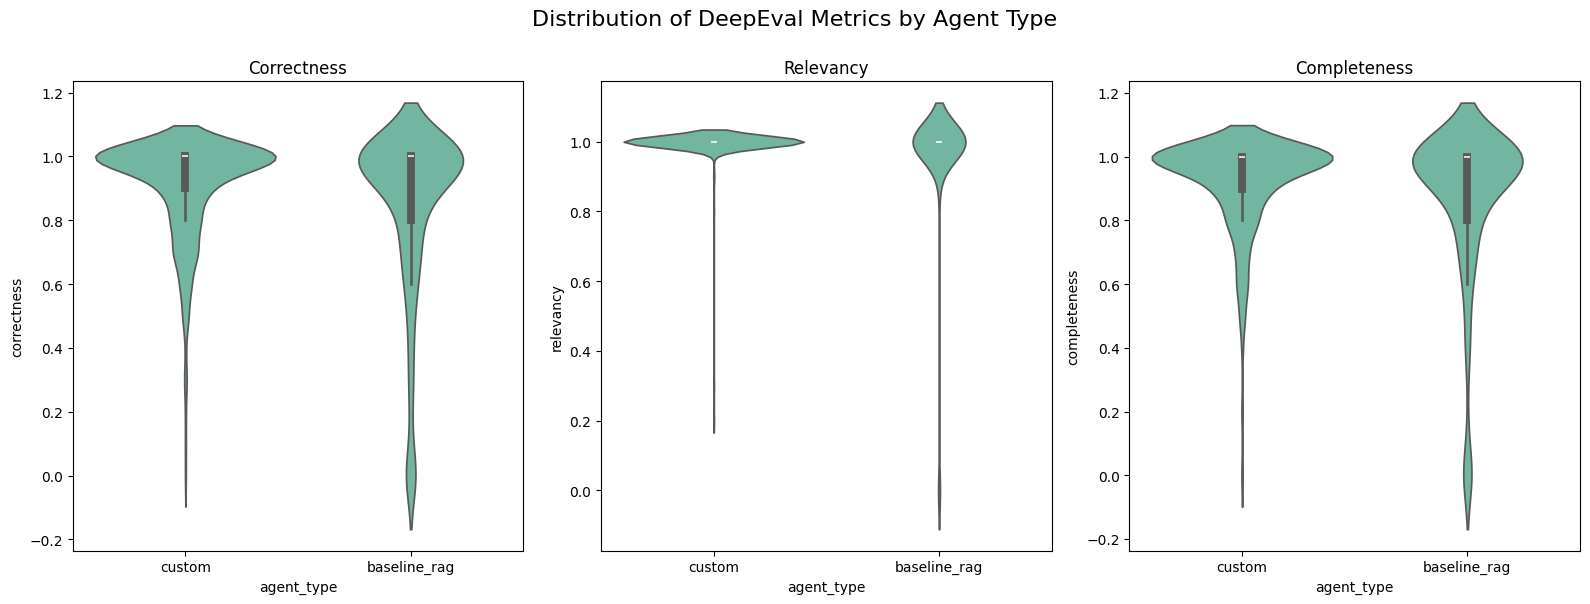

In [47]:
fig, ax = plt.subplots(figsize=(16, 6), ncols=3, nrows=1)
for metric in ["correctness", "relevancy", "completeness"]:
     sns.violinplot(df, 
                    x = "agent_type", 
                    y = metric, 
                    ax=ax[["correctness", "relevancy", "completeness"].index(metric)])
     ax[["correctness", "relevancy", "completeness"].index(metric)].set_title(metric.capitalize())
plt.suptitle("Distribution of DeepEval Metrics by Agent Type", y = 1.0, fontsize = 16)
plt.tight_layout()
fig.savefig(f'../thesis/figures/deep_eval_violin.png') if save_figures else None

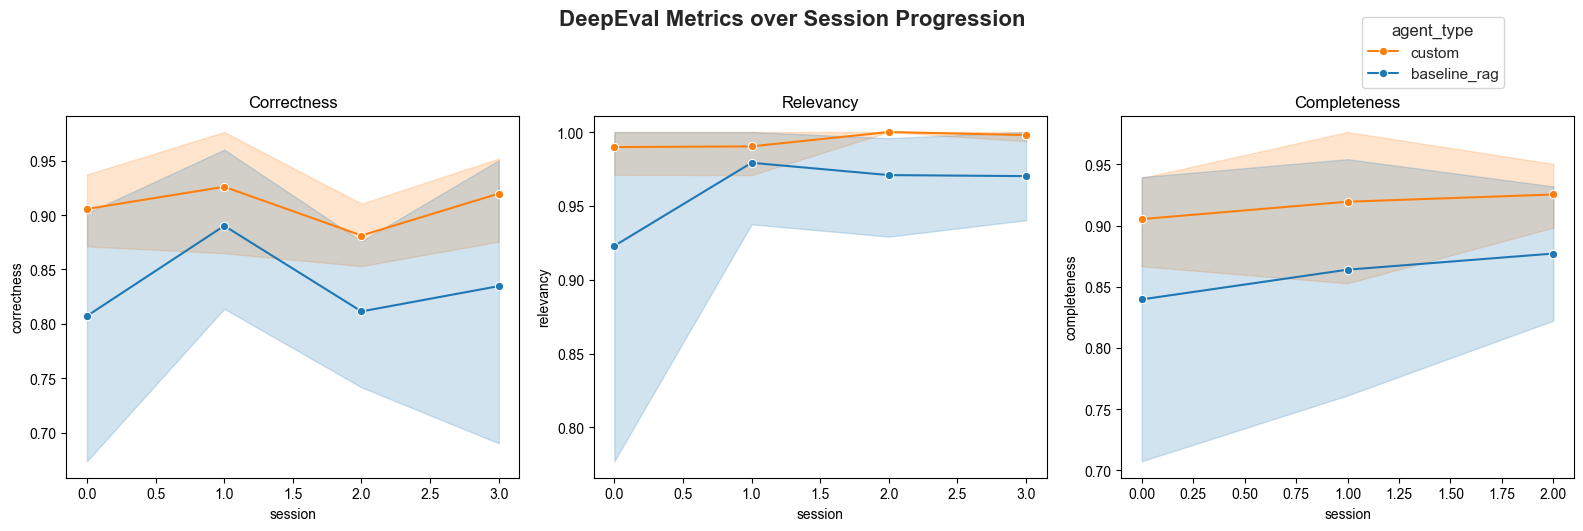

In [48]:
dfs = df.groupby(by = ["agent_type", "llm_model","dataset_name",  "session",],).agg({"correctness" : "mean", 
                                                         "relevancy" : "mean",
                                                         "completeness" : "mean",
                                                         "bert_f1" : "mean",
                                                         "s_bert_similarity" : "mean",
                                                         "duration_seconds" : "mean",
                                                         "input_tokens" : "mean",
                                                         "output_tokens" : "mean",
                                                         "total_tokens" : "mean"})

plot_df = dfs.reset_index().sort_values("session")

def session_plot_metrics(plot_df, metrics, fig_filename = None):
    fig, ax = plt.subplots(figsize=(16, 5), ncols=len(metrics), nrows=1)
    sns.set_theme(style="white")
    for metric in metrics:
         sns.lineplot(data=plot_df, 
                      x="session", 
                      y=metric, 
                      hue="agent_type", 
                      hue_order=["custom", "baseline_rag"],
                       palette=palette,
                      marker="o", ax=ax[metrics.index(metric)])
         ax[metrics.index(metric)].set_title(metric.capitalize())
    plt.suptitle("DeepEval Metrics over Session Progression", y=1.06, fontsize=16, fontweight="bold")
    handles, labels = ax[0].get_legend_handles_labels()   # hent fra første plot
    fig.legend(handles, labels, title="agent_type", loc="upper right", bbox_to_anchor=(0.95, 1.06))
    for a in ax:
        a.get_legend().remove()
    plt.tight_layout()
    if fig_filename and save_figures:
        plt.savefig(f'../thesis/figures/{fig_filename}.png')


def session_plot_by_dataset(plot_df, metric="correctness", save_fig = save_figures):
    fig, ax = plt.subplots(figsize=(15, 5), ncols=2)

    sns.lineplot(
        data=plot_df.loc[plot_df["dataset_name"] == "THRD-2021-163881"],
        x="session", 
        y=metric, 
        hue="agent_type",
        hue_order=agent_order, 
        palette=palette,
        marker="o", 
        ax=ax[0]
    )
    ax[0].set_title("THRD-2021-163881")

    sns.lineplot(
        data=plot_df.loc[plot_df["dataset_name"] == "TOSL-2024-125319-MIN"],
        x="session", 
        y=metric, 
        hue="agent_type",
        hue_order=agent_order,     
        palette=palette,     
        marker="o", 
        ax=ax[1]
    )
    ax[1].set_title("TOSL-2024-125319-MIN")

    plt.suptitle(f"{metric.capitalize()} over Session Progression by Dataset", y=1.05, fontsize=16, fontweight="bold")

    handles, labels = ax[0].get_legend_handles_labels()   # hent fra første plot
    fig.legend(handles, labels, title="agent_type", loc="upper right", bbox_to_anchor=(0.98, 1.03))

    ax[0].get_legend().remove()
    ax[1].get_legend().remove()

    plt.tight_layout()
    if save_fig:
        plt.savefig(f'../thesis/figures/lineplot_{metric}_by_dataset.png', dpi=300, bbox_inches='tight')


session_plot_metrics(plot_df, metrics = ["correctness", "relevancy", "completeness"], fig_filename = "deep_eval_lineplot")

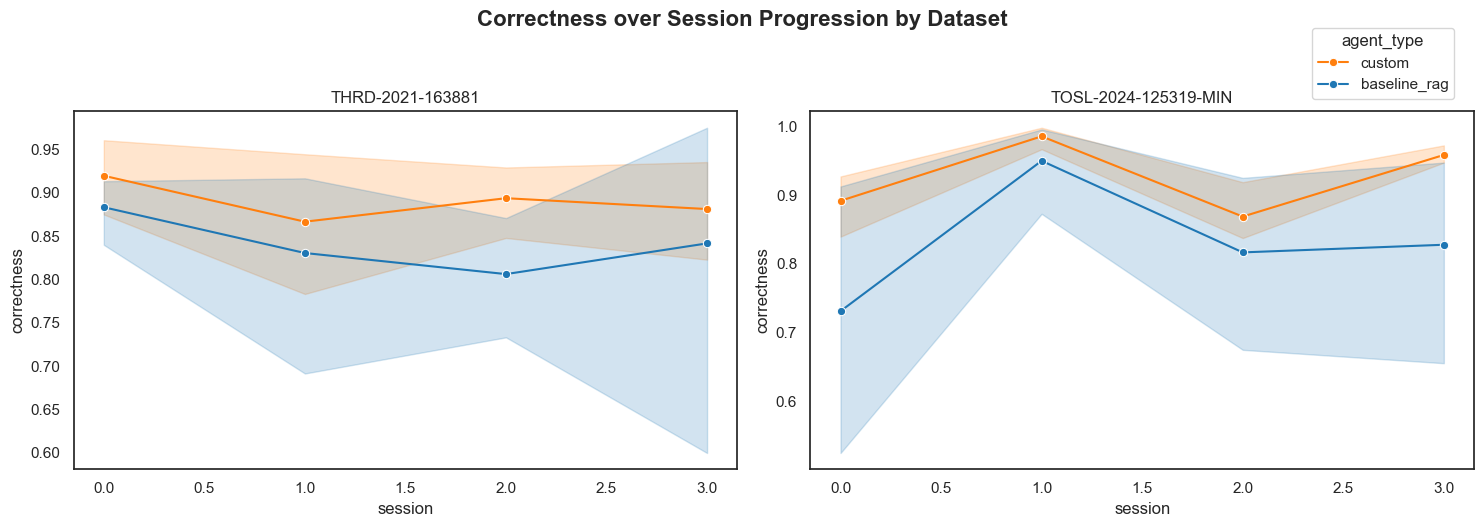

In [49]:
session_plot_by_dataset(plot_df, metric="correctness", save_fig = save_figures)

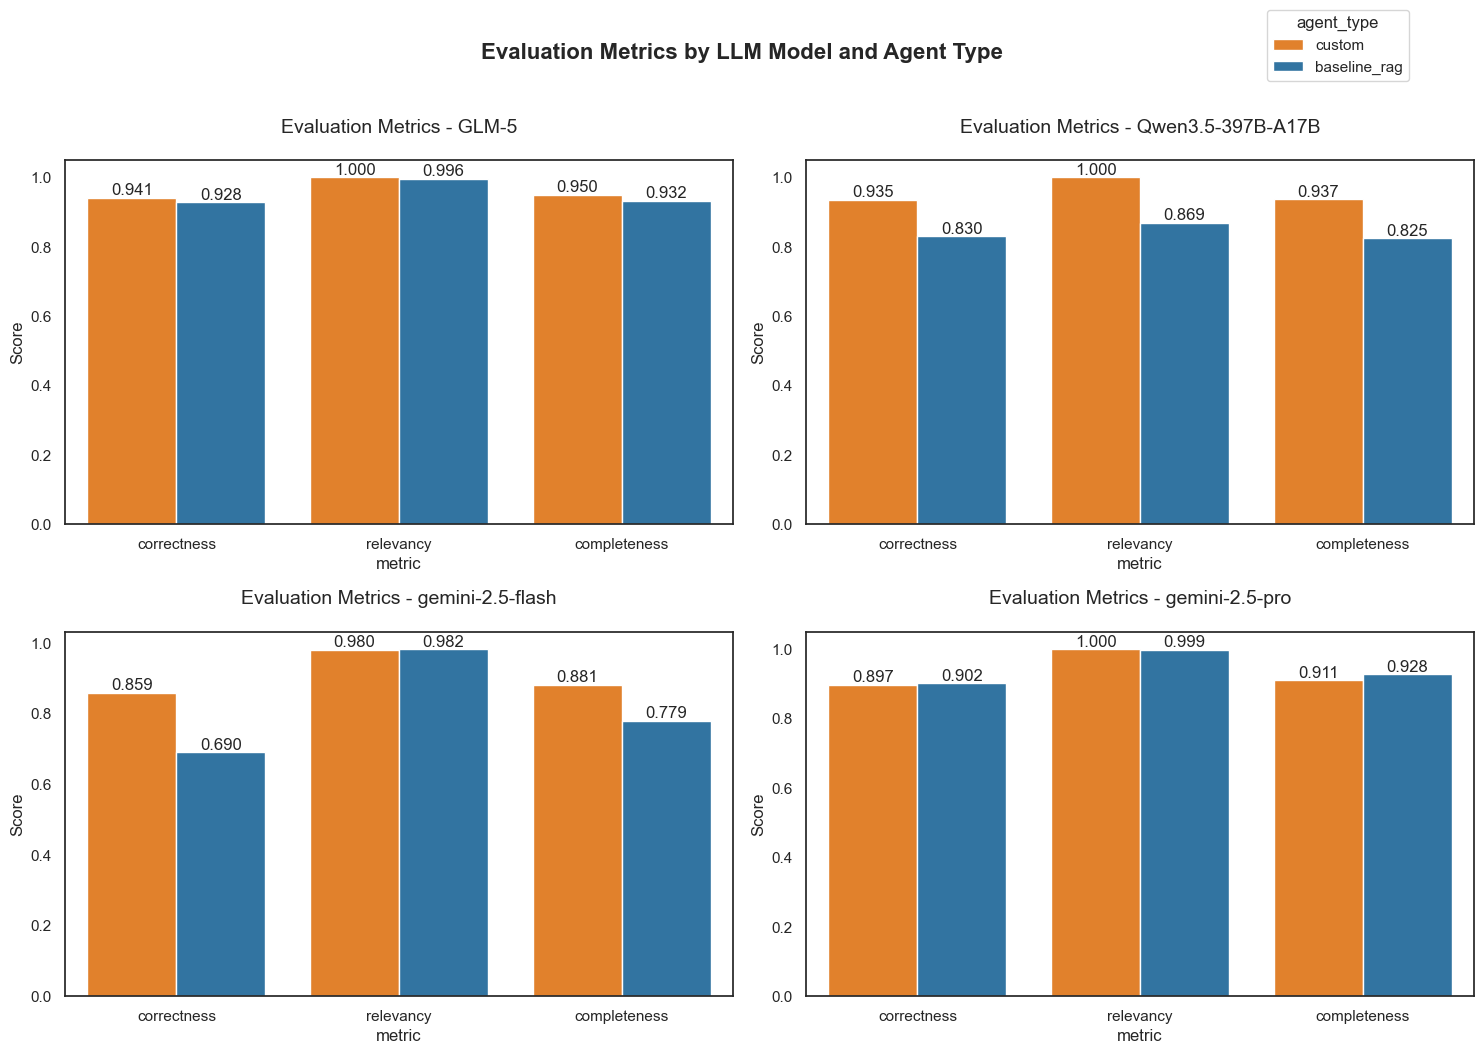

In [56]:

data = df.groupby(["llm_model", "agent_type"]).agg({"correctness" : "mean",
                                                    "relevancy" : "mean",
                                                    "completeness" : "mean",}).reset_index()
plot_data = data.melt(
    id_vars=['llm_model', 'agent_type'],
    value_vars=['correctness', 'relevancy', 'completeness'],
    var_name='metric',
    value_name='score'
)

nunique_models = plot_data["llm_model"].nunique()

fig,ax = plt.subplots(figsize=(15, 10), nrows = nunique_models // 2 + nunique_models % 2, ncols = 2)

for idx, model in enumerate(plot_data['llm_model'].unique()):
    row_idx = idx // 2
    col_idx = idx % 2
    model_data = plot_data[plot_data['llm_model'] == model]
    
    sns.barplot(
        data=model_data,
        x='metric',         
        y='score',
        hue='agent_type',
        hue_order=agent_order,
        palette=palette,
        dodge=True,
        ax=ax[row_idx, col_idx]
    )
    handles, labels = ax[row_idx, col_idx].get_legend_handles_labels() 
    ax[row_idx, col_idx].set_title(f'Evaluation Metrics - {model}', fontsize=14, pad=20)
    ax[row_idx, col_idx].set_ylabel('Score')

    ax[row_idx, col_idx].get_legend().remove()
    
    for container in ax[row_idx, col_idx].containers:
        ax[row_idx, col_idx].bar_label(container, fmt='%.3f', padding=0)


fig.legend(handles, labels, title="agent_type", loc="upper right", bbox_to_anchor=(0.95, 1.06))

plt.suptitle('Evaluation Metrics by LLM Model and Agent Type', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
fig.savefig(f'../thesis/figures/deep_eval_barplot_llms.png', 
            dpi=300, bbox_inches='tight',
            ) if save_figures else None

In [180]:
# data = df.loc[df["dataset_name"] == "THRD-2021-163881", :].groupby(["llm_model", "agent_type"]).agg({"correctness" : "mean",
#                                                                                                         "relevancy" : "mean",
#                                                                                                         "completeness" : "mean",}).reset_index()

# plot_data = data.melt(
#     id_vars=['llm_model', 'agent_type'],
#     value_vars=['correctness', 'relevancy', 'completeness'],
#     var_name='metric',
#     value_name='score'
# )

# nunique_models = plot_data["llm_model"].nunique()

# fig,ax = plt.subplots(figsize=(15, 10), nrows = nunique_models // 2 + nunique_models % 2, ncols = 2)

# for idx, model in enumerate(plot_data['llm_model'].unique()):
#     row_idx = idx // 2
#     col_idx = idx % 2
#     model_data = plot_data[plot_data['llm_model'] == model]
    
#     sns.barplot(
#         data=model_data,
#         x='metric',         
#         y='score',
#         hue='agent_type',
#         hue_order=agent_order,
#         palette=palette,
#         dodge=True,
#         ax=ax[row_idx, col_idx]
#     )
#     handles, labels = ax[row_idx, col_idx].get_legend_handles_labels() 
#     ax[row_idx, col_idx].set_title(f'Evaluation Metrics - {model}', fontsize=14, pad=20)
#     ax[row_idx, col_idx].set_ylabel('Score')

#     ax[row_idx, col_idx].get_legend().remove()
    
#     for container in ax[row_idx, col_idx].containers:
#         ax[row_idx, col_idx].bar_label(container, fmt='%.3f', padding=0)

# fig.legend(handles, labels, title="agent_type", loc="upper right", bbox_to_anchor=(0.95, 1.06))

# plt.suptitle('Evaluation Metrics by LLM Model and Agent Type for THRD-2021-163881', fontsize=16, fontweight='bold', y=1.02)
# plt.tight_layout()
# plt.show()
# fig.savefig(f'../thesis/figures/deep_eval_barplot_llms_THRD-2021-163881.png', 
#             dpi=300, bbox_inches='tight',
#             ) if save_figures else None

In [179]:
# data = df.loc[df["dataset_name"] == "TOSL-2024-125319-MIN", :].groupby(["llm_model", "agent_type"]).agg({"correctness" : "mean",
#                                                                                                         "relevancy" : "mean",
#                                                                                                         "completeness" : "mean",}).reset_index()

# plot_data = data.melt(
#     id_vars=['llm_model', 'agent_type'],
#     value_vars=['correctness', 'relevancy', 'completeness'],
#     var_name='metric',
#     value_name='score'
# )

# nunique_models = plot_data["llm_model"].nunique()

# fig,ax = plt.subplots(figsize=(15, 10), nrows = nunique_models // 2 + nunique_models % 2, ncols = 2)

# for idx, model in enumerate(plot_data['llm_model'].unique()):
#     row_idx = idx // 2
#     col_idx = idx % 2
#     model_data = plot_data[plot_data['llm_model'] == model]
    
#     sns.barplot(
#         data=model_data,
#         x='metric',         
#         y='score',
#         hue='agent_type',
#         hue_order=agent_order,
#         palette=palette,
#         dodge=True,
#         ax=ax[row_idx, col_idx]
#     )
#     handles, labels = ax[row_idx, col_idx].get_legend_handles_labels() 
#     ax[row_idx, col_idx].set_title(f'Evaluation Metrics - {model}', fontsize=14, pad=20)
#     ax[row_idx, col_idx].set_ylabel('Score')

#     ax[row_idx, col_idx].get_legend().remove()
    
#     for container in ax[row_idx, col_idx].containers:
#         ax[row_idx, col_idx].bar_label(container, fmt='%.3f', padding=0)

# fig.legend(handles, labels, title="agent_type", loc="upper right", bbox_to_anchor=(0.95, 1.06))

# plt.suptitle('Evaluation Metrics by LLM Model and Agent Type for TOSL-2024-125319-MIN', fontsize=16, fontweight='bold', y=1.02)
# plt.tight_layout()
# plt.show()
# fig.savefig(f'../thesis/figures/deep_eval_barplot_llms_TOSL-2024-125319-MIN.png', 
#             dpi=300, bbox_inches='tight',
#             ) if save_figures else None

In [181]:
data = df.groupby(["dataset_name", "llm_model", "agent_type"]).agg({"correctness" : "mean",
                                                            "relevancy" : "mean",
                                                            "completeness" : "mean",})

data_pivot = data.pivot_table(index=["dataset_name", "llm_model"], columns="agent_type", values=["correctness", "relevancy", "completeness"])
data_pivot

completeness            correctness  \
agent_type                             baseline_rag    custom baseline_rag   
dataset_name         llm_model                                               
THRD-2021-163881     GLM-5                 0.880000  0.920690     0.889583   
                     Qwen3.5-397B-A17B     0.936667  0.946667     0.927083   
                     gemini-2.5-flash      0.740000  0.853333     0.664583   
                     gemini-2.5-pro        0.903333  0.870000     0.893750   
TOSL-2024-125319-MIN GLM-5                 0.992308  0.981481     0.970455   
                     Qwen3.5-397B-A17B     0.700000  0.925926     0.726667   
                     gemini-2.5-flash      0.822222  0.911111     0.717778   
                     gemini-2.5-pro        0.955556  0.955556     0.911111   

                                                    relevancy            
agent_type                                custom baseline_rag    custom  
dataset_name         llm_model                                           
THRD-2021-163881     GLM-5              0.927660     0.991667  1.000000  
                     Qwen3.5-397B-A17B  0.943750     0.995833  1.000000  
                     gemini-2.5-flash   0.831250     0.995833  0.979167  
                     gemini-2.5-pro     0.870833     1.000000  1.000000  
TOSL-2024-125319-MIN GLM-5              0.955556     1.000000  1.000000  
                     Qwen3.5-397B-A17B  0.926667     0.733333  1.000000  
                     gemini-2.5-flash   0.888889     0.966667  0.980000  
                     gemini-2.5-pro     0.924444     0.997778  1.000000

In [102]:
data_pivot["diff_completeness"] = data_pivot[("completeness", "custom")] - data_pivot[("completeness", "baseline_rag")]
data_pivot["diff_relevancy"] = data_pivot[("relevancy", "custom")] - data_pivot[("relevancy", "baseline_rag")]
data_pivot["diff_correctness"] = data_pivot[("correctness", "custom")] - data_pivot[("correctness", "baseline_rag")]
data_pivot.loc[:, ["diff_completeness", "diff_relevancy", "diff_correctness"]].groupby("dataset_name").agg("mean")

,diff_completeness,diff_relevancy,diff_correctness
agent_type,,,
dataset_name,,,
THRD-2021-163881,0.032672,-0.001042,0.049623
TOSL-2024-125319-MIN,0.075997,0.070556,0.092386


In [103]:
data_pivot.loc[:, ["diff_completeness", "diff_relevancy", "diff_correctness"]].groupby("dataset_name").agg("var")

,diff_completeness,diff_relevancy,diff_correctness
agent_type,,,
dataset_name,,,
THRD-2021-163881,0.003814,0.000120,0.006727
TOSL-2024-125319-MIN,0.011986,0.017127,0.011846


### Bert metrics

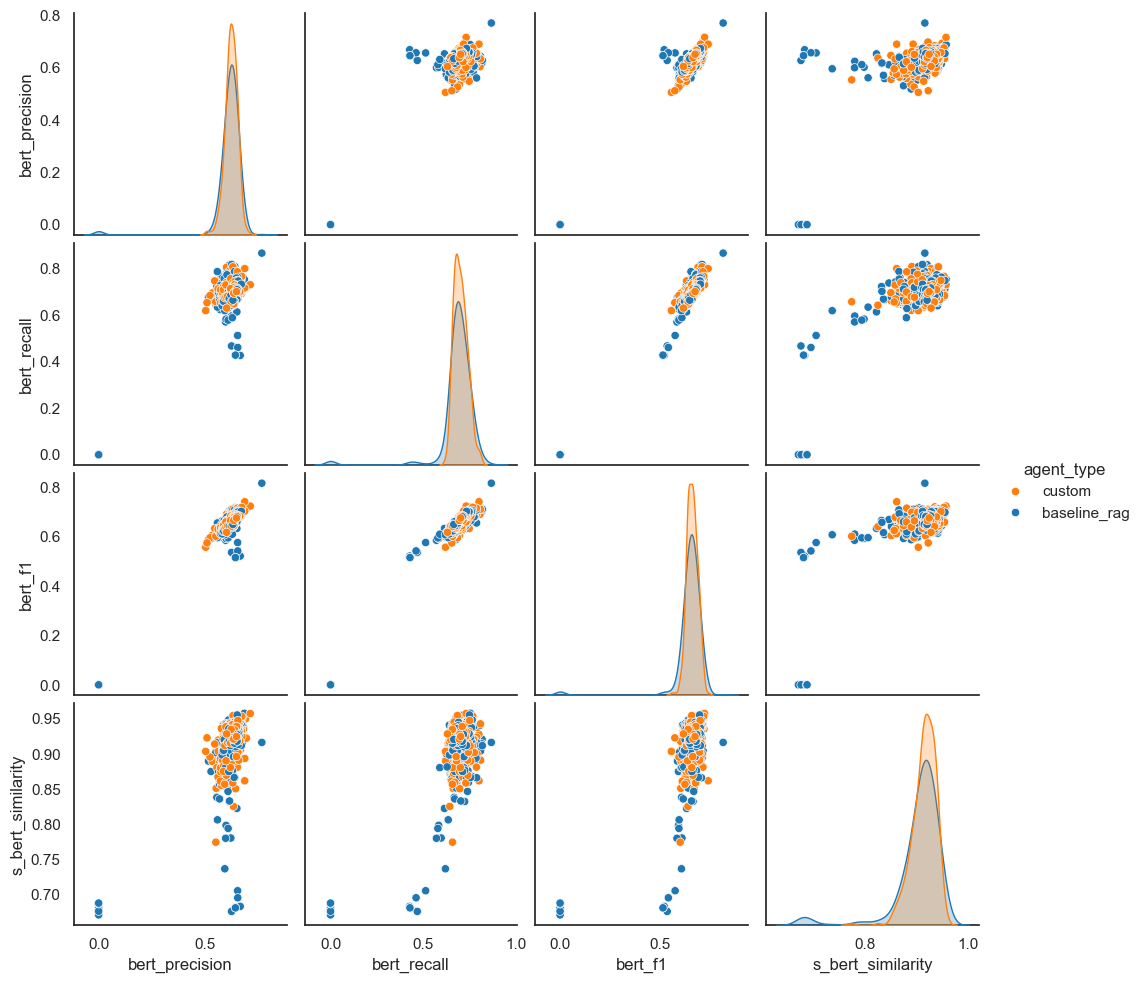

In [123]:
sns.pairplot(df[["bert_precision", "bert_recall", "bert_f1", "s_bert_similarity","llm_model", "agent_type"]], 
             hue = "agent_type",
             hue_order=agent_order,
             palette=palette,
             )
plt.savefig(f'../thesis/figures/bert_pairplot.png') if save_figures else None

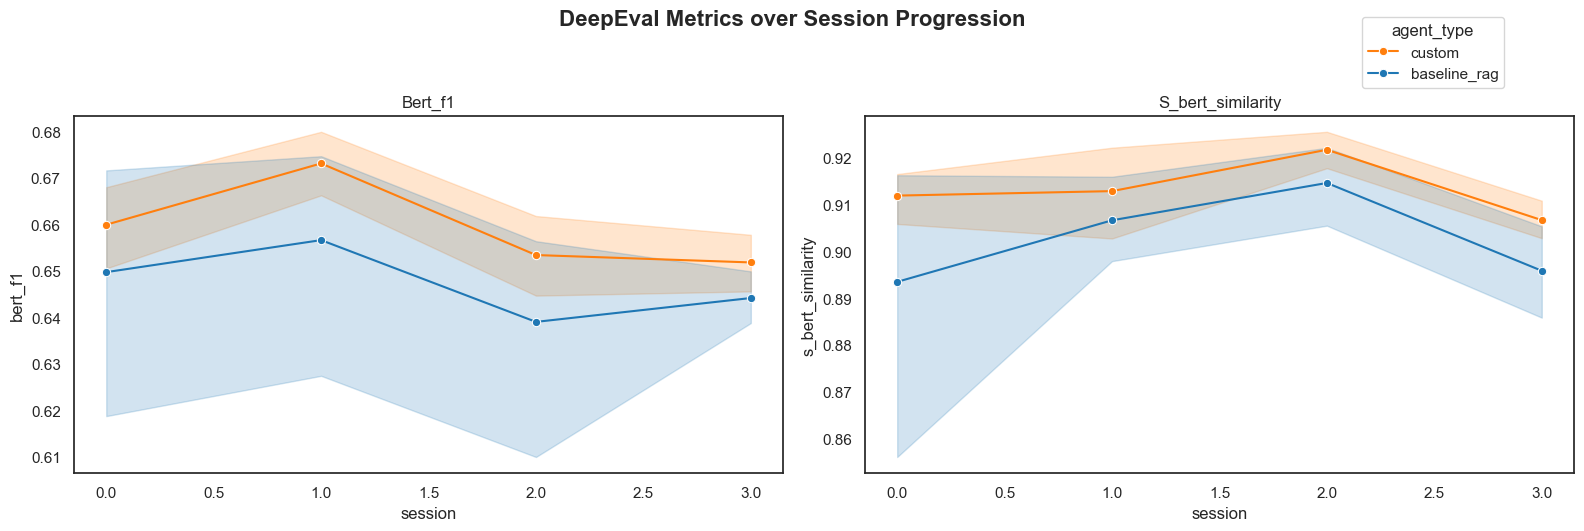

In [124]:
session_plot_metrics(plot_df, metrics = ["bert_f1", "s_bert_similarity"], fig_filename = "bert_lineplot")
plt.savefig(f'../thesis/figures/bert_lineplot.png') if save_figures else None

### Resource metrics
Token counts and time coutns

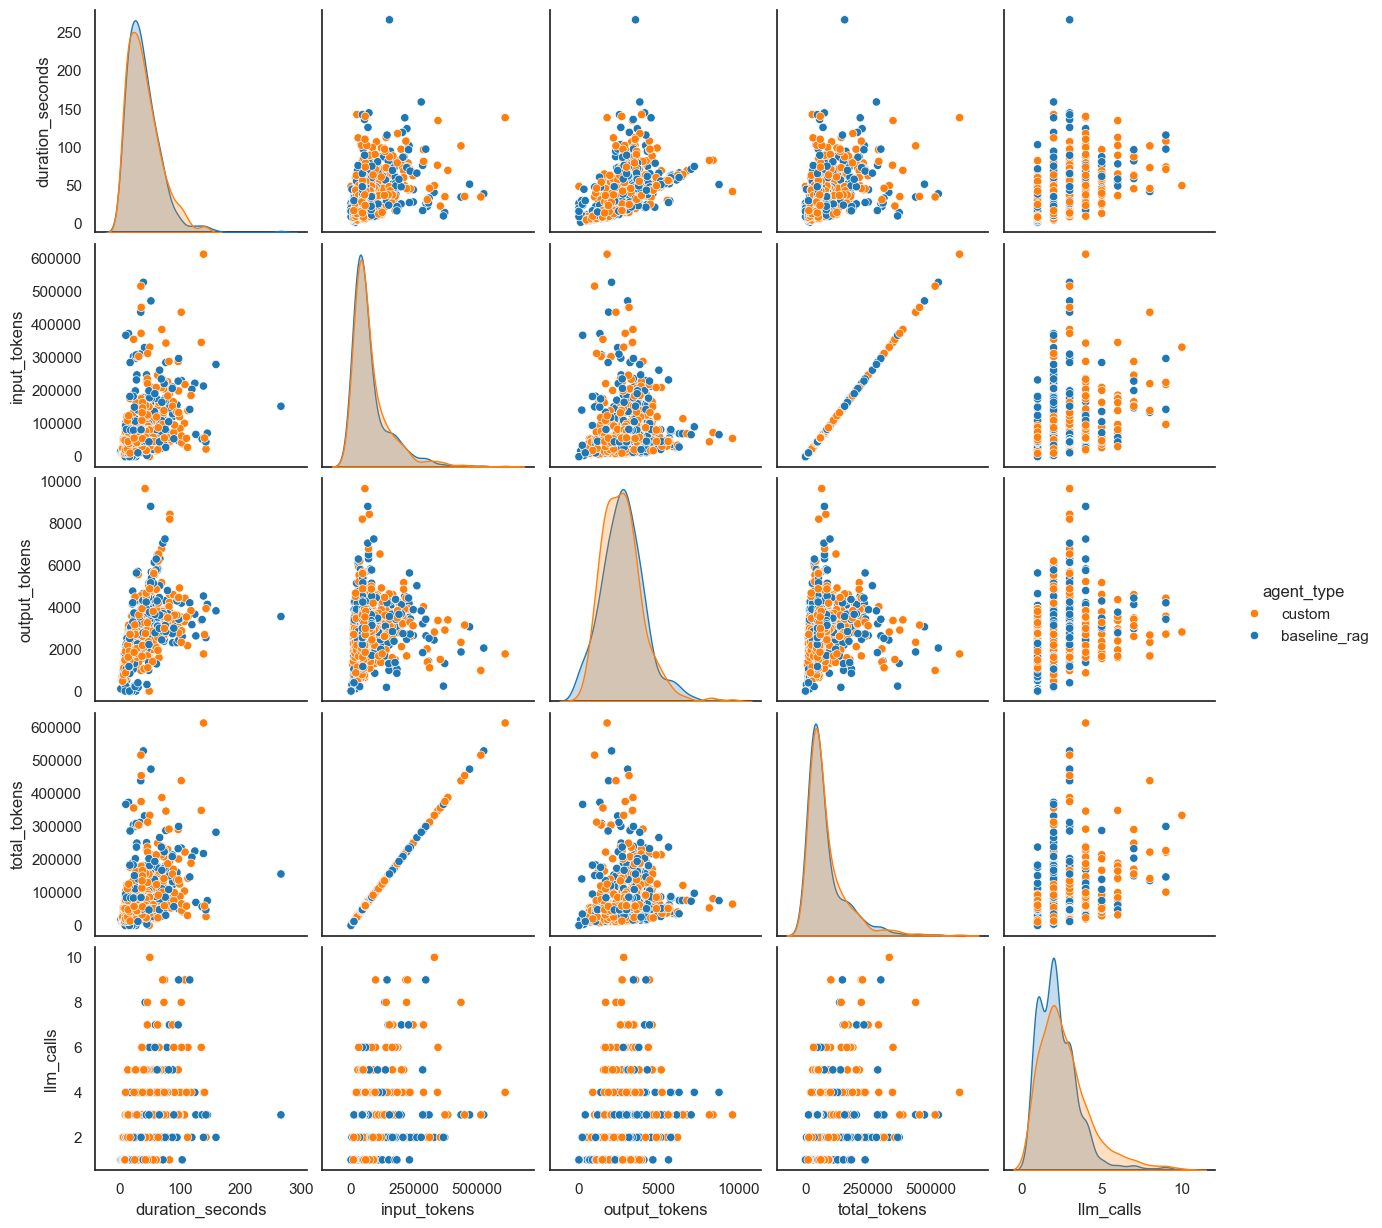

In [125]:
sns.pairplot(df[["duration_seconds", "input_tokens", "output_tokens", "total_tokens" , "llm_calls", "llm_model", "agent_type"]], 
             hue = "agent_type",
             hue_order=agent_order,
             palette=palette,
             )
plt.savefig(f'../thesis/figures/resource_pairplot.png') if save_figures else None

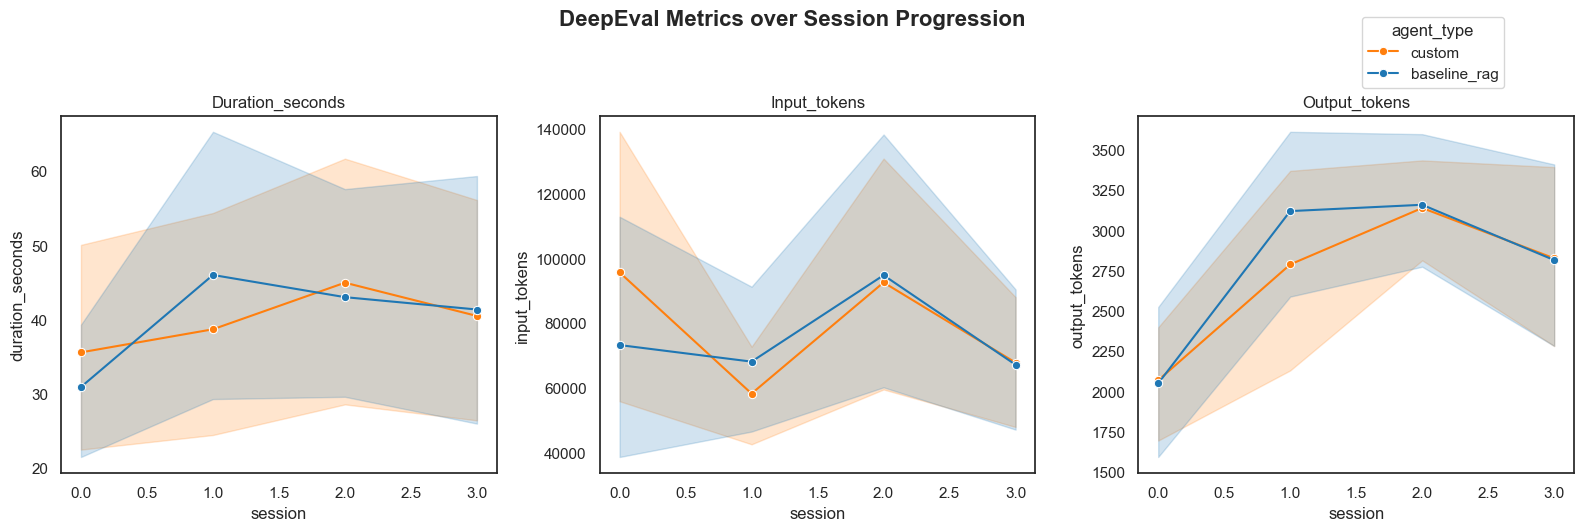

In [126]:
session_plot_metrics(plot_df, metrics = ["duration_seconds", "input_tokens", "output_tokens"], fig_filename = "resource_lineplot")
plt.savefig(f'../thesis/figures/resource_lineplot.png')

### Cost analysis

In [210]:
tokens = df.groupby(["dataset_name", "llm_model", "agent_type"]).agg({
                                                        "input_tokens" : "mean",
                                                        "output_tokens" : "mean",
                                                        "correctness" : "mean",
                                                        "relevancy" : "mean",
                                                        "completeness" : "mean",})

cost_table = {
    "Qwen3.5-397B-A17B": {"in": 0.60, "out": 3.60},
    "GLM-5": {"in": 1.00, "out": 3.20},
    "gemini-2.5-flash": {"in": 0.30, "out": 2.50},
    "gemini-2.5-pro": {"in": 1.25, "out": 10.00},  # <= 200k tokens
}
cost_df = pd.DataFrame(cost_table).T
cost_df = cost_df.reset_index().rename(columns={"index": "llm_model"},)

In [217]:
cost = pd.merge(tokens.reset_index(), cost_df, on="llm_model")
cost["total_cost"] = cost["input_tokens"] * cost["in"] / 1000 + cost["output_tokens"] * cost["out"] / 1000
cost.groupby("dataset_name").agg({"total_cost": "mean"}).to_dict()

{'total_cost': {'THRD-2021-163881': 62.55656146387411,
  'TOSL-2024-125319-MIN': 92.99441630050504}}

In [215]:
#since the overall usage in TOSL er so much higher than THRD we use rank to level them out for comparison across datasets
cost["rank_cost"] = (
    cost.groupby("dataset_name")["total_cost"]
    .transform(lambda x: x.rank(pct=True))
)
cost.head()

,dataset_name,llm_model,agent_type,input_tokens,output_tokens,correctness,relevancy,completeness,in,out,total_cost,rank_cost
0,THRD-2021-163881,GLM-5,baseline_rag,83087.979167,2809.3125,0.889583,0.991667,0.880000,1.0,3.2,92.077779,0.875
1,THRD-2021-163881,GLM-5,custom,94500.425532,2675.148936,0.927660,1.000000,0.920690,1.0,3.2,103.060902,1.000
2,THRD-2021-163881,Qwen3.5-397B-A17B,baseline_rag,67201.104167,3091.5625,0.927083,0.995833,0.936667,0.6,3.6,51.450288,0.375
3,THRD-2021-163881,Qwen3.5-397B-A17B,custom,86769.770833,2782.104167,0.943750,1.000000,0.946667,0.6,3.6,62.077437,0.500
4,THRD-2021-163881,gemini-2.5-flash,baseline_rag,34257.5,2039.666667,0.664583,0.995833,0.740000,0.3,2.5,15.376417,0.250


In [204]:
cost["actual_in_cost"] = cost["in"] * cost["input_tokens"] / 1000
cost["actual_in_cost_rank"] = cost.groupby("dataset_name")["actual_in_cost"].transform(lambda x: x.rank(pct=True))
plot_actual_in_cost = cost.groupby(["llm_model", "agent_type"]).agg({"actual_in_cost_rank": "mean",
                               "in" : "mean"})
plot_actual_in_cost

actual_in_cost_rank    in
llm_model         agent_type                             
GLM-5             baseline_rag                0.875  1.00
                  custom                      1.000  1.00
Qwen3.5-397B-A17B baseline_rag                0.500  0.60
                  custom                      0.625  0.60
gemini-2.5-flash  baseline_rag                0.250  0.30
                  custom                      0.125  0.30
gemini-2.5-pro    baseline_rag                0.500  1.25
                  custom                      0.625  1.25

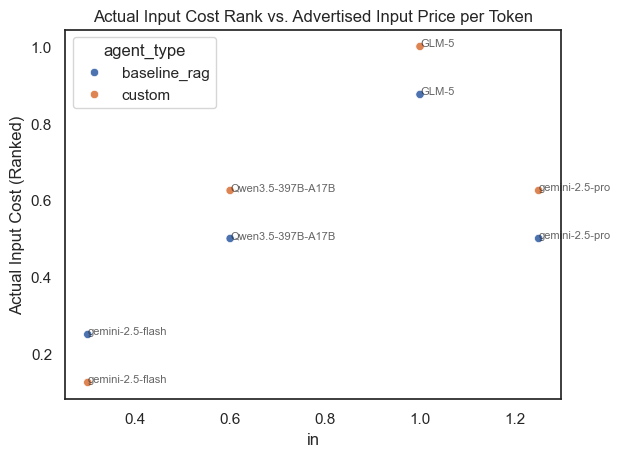

In [214]:
sns.scatterplot(data = plot_actual_in_cost,x = "in", y = "actual_in_cost_rank", hue = "agent_type")
for _, row in plot_actual_in_cost.reset_index().iterrows():
    plt.annotate(
        row["llm_model"],
        (row["in"], row["actual_in_cost_rank"]),
        fontsize=8,
        alpha=0.7
    )

plt.ylabel("Actual Input Cost (Ranked)")
plt.title("Actual Input Cost Rank vs. Advertised Input Price per Token")
plt.savefig(f'../thesis/figures/actual_input_cost.png', dpi=300, bbox_inches='tight') #if save_figures else None

In [208]:
agg_cost = cost.groupby(["llm_model","agent_type"]).agg({"rank_cost": "mean", 
                               "correctness": "mean",
                               "relevancy": "mean",
                               "completeness": "mean",
                               })
agg_cost

rank_cost  correctness  relevancy  \
llm_model         agent_type                                        
GLM-5             baseline_rag     0.8750     0.930019   0.995833   
                  custom           1.0000     0.941608   1.000000   
Qwen3.5-397B-A17B baseline_rag     0.4375     0.826875   0.864583   
                  custom           0.4375     0.935208   1.000000   
gemini-2.5-flash  baseline_rag     0.2500     0.691181   0.981250   
                  custom           0.1250     0.860069   0.979583   
gemini-2.5-pro    baseline_rag     0.6875     0.902431   0.998889   
                  custom           0.6875     0.897639   1.000000   

                                completeness  
llm_model         agent_type                  
GLM-5             baseline_rag      0.936154  
                  custom            0.951086  
Qwen3.5-397B-A17B baseline_rag      0.818333  
                  custom            0.936296  
gemini-2.5-flash  baseline_rag      0.781111  
                  custom            0.882222  
gemini-2.5-pro    baseline_rag      0.929444  
                  custom            0.912778

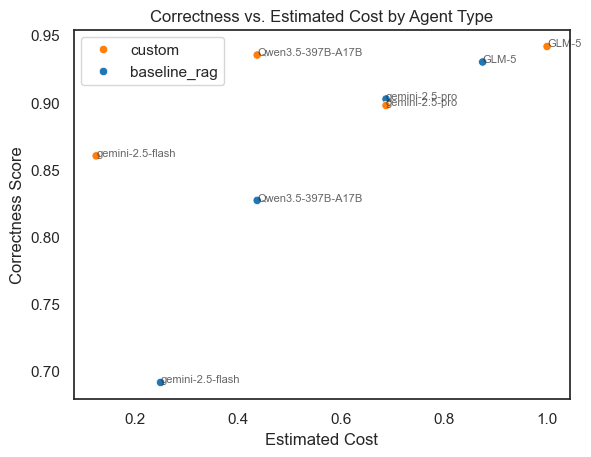

In [161]:
sns.scatterplot(data=agg_cost.reset_index(), x="rank_cost", y="correctness", hue="agent_type", palette=palette, hue_order=agent_order)
plt.title("Correctness vs. Estimated Cost by Agent Type")
plt.xlabel("Estimated Cost")
plt.ylabel("Correctness Score")
for _, row in agg_cost.reset_index().iterrows():
    plt.annotate(
        row["llm_model"],
        (row["rank_cost"], row["correctness"]),
        fontsize=8,
        alpha=0.7
    )
plt.legend()
plt.savefig(f'../thesis/figures/cost_vs_correctness.png') if save_figures else None

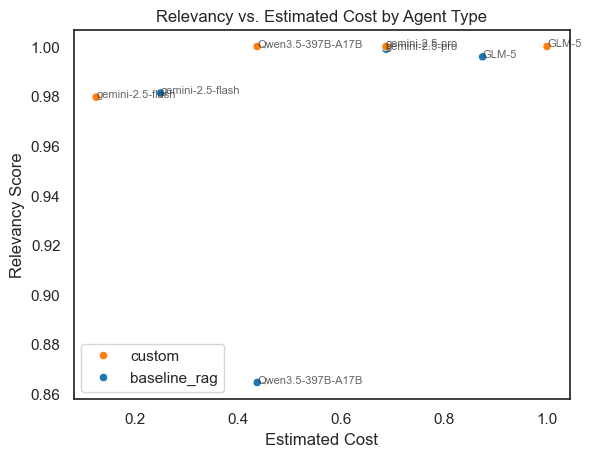

In [165]:
sns.scatterplot(data=agg_cost.reset_index(), x="rank_cost", y="relevancy", hue="agent_type", palette=palette, hue_order=agent_order)
plt.title("Relevancy vs. Estimated Cost by Agent Type")
plt.xlabel("Estimated Cost")
plt.ylabel("Relevancy Score")
for _, row in agg_cost.reset_index().iterrows():
    plt.annotate(
        row["llm_model"],
        (row["rank_cost"], row["relevancy"]),
        fontsize=8,
        alpha=0.7
    )
plt.legend()
plt.savefig(f'../thesis/figures/cost_vs_relevancy.png') if save_figures else None

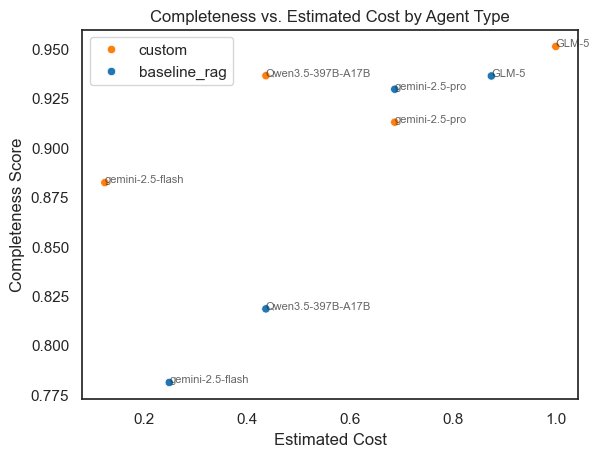

In [164]:
sns.scatterplot(data=agg_cost.reset_index(), x="rank_cost", y="completeness", hue="agent_type", palette=palette, hue_order=agent_order)
plt.title("Completeness vs. Estimated Cost by Agent Type")
plt.xlabel("Estimated Cost")
plt.ylabel("Completeness Score")
for _, row in agg_cost.reset_index().iterrows():
    plt.annotate(
        row["llm_model"],
        (row["rank_cost"], row["completeness"]),
        fontsize=8,
        alpha=0.7
    )
plt.legend()
plt.savefig(f'../thesis/figures/cost_vs_completeness.png') if save_figures else None

In [166]:
agg_cost

rank_cost  correctness  relevancy  \
llm_model         agent_type                                        
GLM-5             baseline_rag     0.8750     0.930019   0.995833   
                  custom           1.0000     0.941608   1.000000   
Qwen3.5-397B-A17B baseline_rag     0.4375     0.826875   0.864583   
                  custom           0.4375     0.935208   1.000000   
gemini-2.5-flash  baseline_rag     0.2500     0.691181   0.981250   
                  custom           0.1250     0.860069   0.979583   
gemini-2.5-pro    baseline_rag     0.6875     0.902431   0.998889   
                  custom           0.6875     0.897639   1.000000   

                                completeness  
llm_model         agent_type                  
GLM-5             baseline_rag      0.936154  
                  custom            0.951086  
Qwen3.5-397B-A17B baseline_rag      0.818333  
                  custom            0.936296  
gemini-2.5-flash  baseline_rag      0.781111  
                  custom            0.882222  
gemini-2.5-pro    baseline_rag      0.929444  
                  custom            0.912778

### Combined
Deep eval, bert & resource

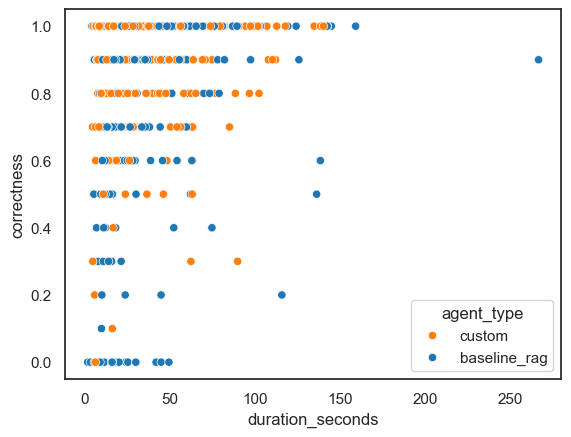

In [127]:
sns.scatterplot(df, x = "duration_seconds", 
                y = "correctness", 
                hue = "agent_type",
                hue_order=agent_order,
                palette=palette,
                )
plt.savefig(f'../thesis/figures/duration_vs_correctness.png') if save_figures else None

## Statistical Modeling

In [13]:
import numpy as np
from scipy import stats 

class StatisticalMetrics:
    def __init__(self, significance_level: float = 0.05):
        self.significance_level = significance_level

    def check_normality(self, values: list[float] | np.ndarray):
        """
        Performs Shapiro-Wilk test for normality.
        """
        result = stats.shapiro(values)
        is_normal = result.pvalue > self.significance_level
        status = "✅ Normal distribution" if is_normal else "❌ Not normal distribution"
        print(f"{status} (p={result.pvalue:.2e})")
        return is_normal

    def mann_whitney_u_test(self, group_a: list[float] | np.ndarray, group_b: list[float] | np.ndarray, alternative: Literal["greater","less","two-sided"] = 'greater'):
        """
        Non-parametric alternative to Independent T-test (for 2 groups).
        Does not assume normality.
        """
        u_stat, p = stats.mannwhitneyu(group_a, group_b, alternative=alternative)
        print(f"\n--- Mann-Whitney U Test (Non-parametric T-test) ---")
        print(f"U-statistic: {u_stat:.2f}, p-value: {p:.4e}")
        
        if p < self.significance_level:
            print(f"✅ Group A is significantly greater than Group B (p < {self.significance_level})")
        else:
            print(f"❌ No significant difference (p >= {self.significance_level})")
        return p

    def kruskal_wallis_test(self, *groups: list[float] | np.ndarray):
        """
        Non-parametric alternative to One-way ANOVA (for 3+ groups).
        Tests if at least one group comes from a different distribution.
        """
        h_stat, p = stats.kruskal(*groups)
        print(f"\n--- Kruskal-Wallis Test (Non-parametric ANOVA) ---")
        print(f"H-statistic: {h_stat:.2f}, p-value: {p:.4e}")
        
        if p < self.significance_level:
            print(f"✅ Significant difference exists between at least two groups.")
        else:
            print(f"❌ No significant difference between the groups.")
        return p

    def wilcoxon_signed_rank_test(self, before: list[float], after: list[float], alternative: Literal["greater","less","two-sided"] = 'greater'):
        """
        Non-parametric alternative to Paired T-test.
        Use this if the '0-1 values' are from the same subjects/items at different times.
        """
        stat, p = stats.wilcoxon(before, after, alternative=alternative)
        print(f"\n--- Wilcoxon Signed-Rank Test (Paired) ---")
        print(f"Statistic: {stat:.2f}, p-value: {p:.4e}")
        if p < self.significance_level:
            print(f"✅ 'After' is significantly greater than 'Before' (p < {self.significance_level})")
        else:
            print(f"❌ No significant difference (p >= {self.significance_level})")
        return p
    def t_test(self, custom_eval: list[float] | np.ndarray, comparison_eval: list[float] | np.ndarray, alternative: Literal["greater","less","two-sided"] = 'greater'):
        t_stat, p = stats.ttest_ind(custom_eval, comparison_eval, equal_var=False, alternative=alternative)
        print(f"Custom vs. Comparison: t={t_stat:.2f}, p={p:.4f}")
        if p < self.significance_level:
            print("✅ Custom beats Comparison (p<0.05).")
        else:
            print("❌ No significant difference (p>=0.05).")


In [14]:
df["agent_type"].value_counts()

agent_type
custom          371
baseline_rag    371
Name: count, dtype: int64

### Quality metrics

❌ Not normal distribution (p=4.55e-27)
❌ Not normal distribution (p=5.98e-39)
❌ Not normal distribution (p=2.75e-22)


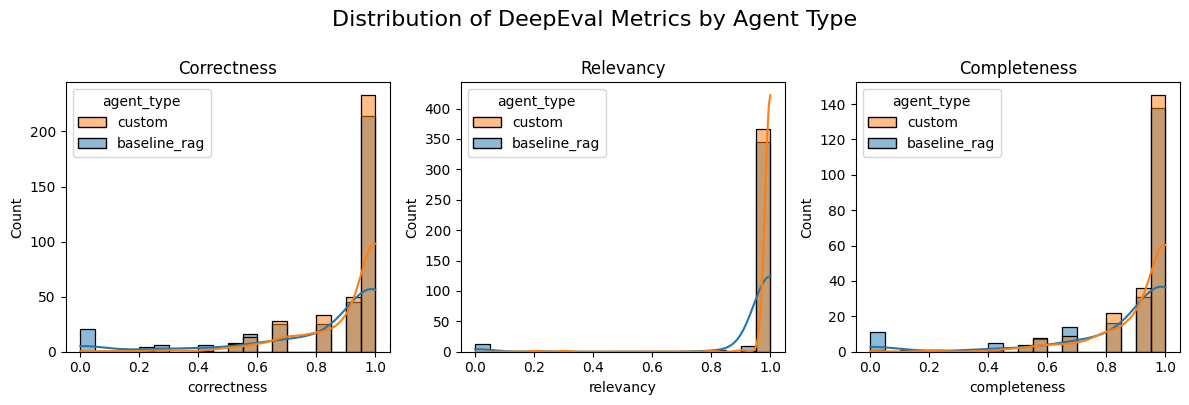

In [15]:
for metric in ["correctness", "relevancy", "completeness"]:
    StatisticalMetrics().check_normality(df.loc[df["agent_type"] == "custom", metric].dropna())
fig, ax = plt.subplots(figsize=(12, 4), ncols=3, nrows=1)
for i, metric in enumerate(["correctness", "relevancy", "completeness"]):
    sns.histplot(df, x = metric, 
                 hue = "agent_type", 
                 hue_order=agent_order,
                    palette=palette,
                 kde = True, 
                 bins = 20, 
                 ax=ax[i])
    ax[i].set_title(metric.capitalize())

plt.suptitle("Distribution of DeepEval Metrics by Agent Type", y = 1.0, fontsize = 16)
plt.tight_layout()
plt.savefig(f'../thesis/figures/deepeval_distribution.png') if save_figures else None

In [16]:
#Since not normally distributed, we use Mann-Whitney U test (non-parametric alternative to T-test)
sm = StatisticalMetrics()
for metric in ["correctness", "relevancy", "completeness"]:
    print(f"\nTesting metric: --{metric.upper()}--")
    print(f'Custom Mean, Std: {df.loc[df["agent_type"] == "custom", metric].mean():.4f} ± {df.loc[df["agent_type"] == "custom", metric].std():.4f}')
    print(f'RAG Mean, Std: {df.loc[df["agent_type"] == "baseline_rag", metric].mean():.4f} ± {df.loc[df["agent_type"] == "baseline_rag", metric].std():.4f}')
    custom_data = df.loc[df["agent_type"] == "custom", metric].dropna()
    rag_data = df.loc[df["agent_type"] == "baseline_rag", metric].dropna()
    sm.mann_whitney_u_test(group_a=custom_data, group_b=rag_data)


Testing metric: --CORRECTNESS--
Custom Mean, Std: 0.9081 ± 0.1587
RAG Mean, Std: 0.8375 ± 0.2747

--- Mann-Whitney U Test (Non-parametric T-test) ---
U-statistic: 74780.50, p-value: 1.0336e-02
✅ Group A is significantly greater than Group B (p < 0.05)

Testing metric: --RELEVANCY--
Custom Mean, Std: 0.9949 ± 0.0565
RAG Mean, Std: 0.9612 ± 0.1823

--- Mann-Whitney U Test (Non-parametric T-test) ---
U-statistic: 72733.00, p-value: 5.5377e-05
✅ Group A is significantly greater than Group B (p < 0.05)

Testing metric: --COMPLETENESS--
Custom Mean, Std: 0.9194 ± 0.1466
RAG Mean, Std: 0.8656 ± 0.2509

--- Mann-Whitney U Test (Non-parametric T-test) ---
U-statistic: 27278.50, p-value: 1.0617e-01
❌ No significant difference (p >= 0.05)


5.5377e-05


In [17]:
def check_metric(metric):
        StatisticalMetrics().check_normality(df.loc[df["agent_type"] == "custom", metric].dropna())
        print(f'Avg, Std {metric} for custom agent: {df.loc[df["agent_type"] == "custom", metric].mean():.2f} ± {df.loc[df["agent_type"] == "custom", metric].std():.2f}')
        print(f'Avg, Std {metric} for baseline_rag agent: {df.loc[df["agent_type"] == "baseline_rag", metric].mean():.2f} ± {df.loc[df["agent_type"] == "baseline_rag", metric].std():.2f}')
        sns.histplot(df, x = metric, 
                     hue = "agent_type", 
                     hue_order=agent_order,
                        palette=palette,
                     kde = True, bins = 20)

❌ Not normal distribution (p=1.55e-24)
Avg, Std input_tokens for custom agent: 79319.43 ± 82405.14
Avg, Std input_tokens for baseline_rag agent: 75395.10 ± 78670.35


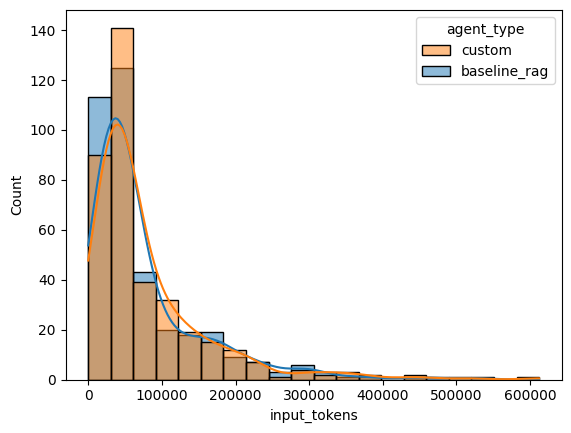

In [18]:
check_metric("input_tokens")

In [19]:
print(f"\nTesting metric: input_tokens")
custom_data = df.loc[df["agent_type"] == "custom", "input_tokens"].dropna()
rag_data = df.loc[df["agent_type"] == "baseline_rag", "input_tokens"].dropna()
sm.mann_whitney_u_test(group_a=custom_data, group_b=rag_data, alternative="less")


Testing metric: input_tokens

--- Mann-Whitney U Test (Non-parametric T-test) ---
U-statistic: 71961.00, p-value: 8.5902e-01
❌ No significant difference (p >= 0.05)


np.float64(0.8590243282360704)

❌ Not normal distribution (p=9.04e-14)
Avg, Std duration_seconds for custom agent: 39.76 ± 27.21
Avg, Std duration_seconds for baseline_rag agent: 39.61 ± 28.92


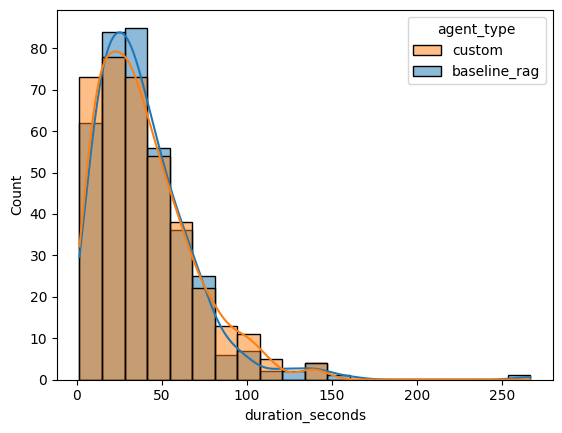

In [20]:
check_metric("duration_seconds")

In [21]:
print(f"\nTesting metric: duration_seconds")
custom_data = df.loc[df["agent_type"] == "custom", "duration_seconds"].dropna()
rag_data = df.loc[df["agent_type"] == "baseline_rag", "duration_seconds"].dropna()
sm.mann_whitney_u_test(group_a=custom_data, group_b=rag_data, alternative="less")


Testing metric: duration_seconds

--- Mann-Whitney U Test (Non-parametric T-test) ---
U-statistic: 69100.00, p-value: 5.3821e-01
❌ No significant difference (p >= 0.05)


np.float64(0.5382054162210212)

### Self consistency

In [22]:
def pairwise_cosine_similarities(embeddings):
    """
    Tar inn en liste av embeddings (liste av list[float] eller array)
    Returnerer en matrise med alle pairwise cosine similarities
    """
    embeddings = [ast.literal_eval(emb) if isinstance(emb, str) else emb for emb in embeddings]
            
    emb = np.array(embeddings, dtype=float)
    norms = np.linalg.norm(emb, axis=1, keepdims=True)
    normalized = emb / norms                     # L2-normaliser
    sim_matrix = normalized @ normalized.T       # alle mot alle
    return sim_matrix

def self_consistency_score(embeddings, method="mean"):
    """
    Regner ut en self-consistency score for en gruppe embeddings.
    
    method:
      - 'mean'     → gjennomsnitt av alle unike pairwise similarities (vanligst)
      - 'min'      → den laveste pairwise similarity (strengeste)
      - 'median'   → median av pairwise similarities
    """
    if len(embeddings) < 2:
        return 1.0  # kun én embedding → perfekt consistency
    
    sim_matrix = pairwise_cosine_similarities(embeddings)
    
    # Ta bare upper triangle (uten diagonal)
    triu_idx = np.triu_indices_from(sim_matrix, k=1)
    pairwise_sims = sim_matrix[triu_idx]
    
    if method == "mean":
        return float(pairwise_sims.mean())
    elif method == "median":
        return float(np.median(pairwise_sims))
    elif method == "min":
        return float(pairwise_sims.min())
    else:
        raise ValueError("method må være 'mean', 'median' eller 'min'")

In [23]:
embeddings = df.groupby(["llm_model", "query_id", "agent_type"])["embedded_actual_output"].apply(list)
embeddings = embeddings.to_frame(name="embedded_actual_output").reset_index()
embeddings["self_consistency"] = embeddings["embedded_actual_output"].apply(self_consistency_score)

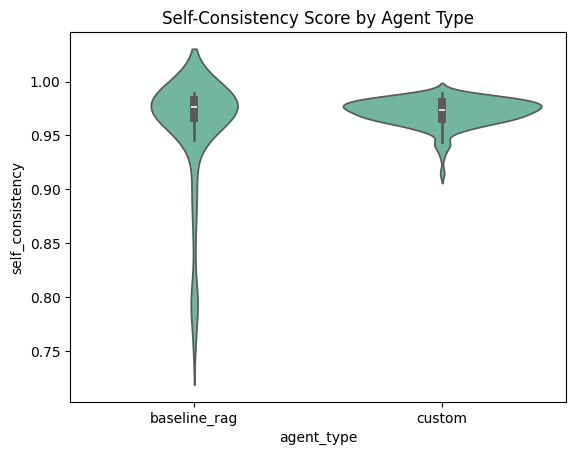

In [24]:
sns.violinplot(embeddings, x = "agent_type", y = "self_consistency")
plt.title("Self-Consistency Score by Agent Type")
plt.savefig(f'../thesis/figures/self_consistency_violin.png')

<Axes: xlabel='self_consistency', ylabel='Count'>

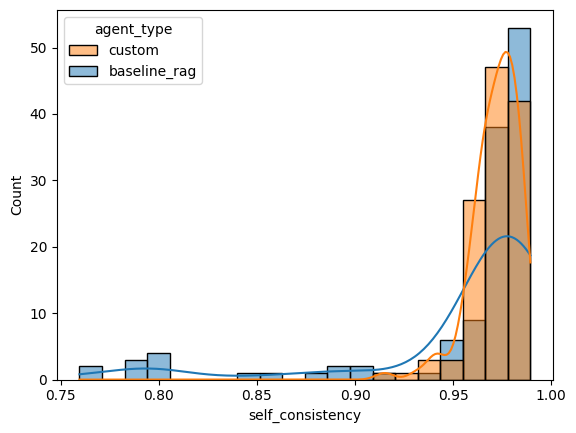

In [25]:
sns.histplot(embeddings, 
             x = "self_consistency", 
             hue = "agent_type", 
             hue_order=agent_order,
                palette=palette,
             kde = True, 
             bins = 20)

In [26]:
sm.mann_whitney_u_test(
    group_a=embeddings.loc[embeddings["agent_type"] == "custom", "self_consistency"].dropna(),
    group_b=embeddings.loc[embeddings["agent_type"] == "baseline_rag", "self_consistency"].dropna(),
    alternative="greater"
)


--- Mann-Whitney U Test (Non-parametric T-test) ---
U-statistic: 7039.00, p-value: 8.7490e-01
❌ No significant difference (p >= 0.05)


np.float64(0.8749011141238949)

## Variance analysis

The test statistic is:

$$
\begin{equation}
    W = \frac{N - k}{k - 1} \cdot
        \frac{\displaystyle\sum_{i=1}^{k} N_i \bigl(\bar{Z}_{i\cdot} - \bar{Z}_{\cdot\cdot}\bigr)^2}
             {\displaystyle\sum_{i=1}^{k} \sum_{j=1}^{N_i} \bigl(Z_{ij} - \bar{Z}_{i\cdot}\bigr)^2}
\end{equation}
$$

where:
- $k$ = number of groups (here $k = 2$: custom and baseline)
- $N$ = total number of observations across both groups
- $N_i$ = number of observations in group $i$
- $Z_{ij} = \lvert Y_{ij} - \bar{Y}_{i\cdot} \rvert$, the absolute deviation of observation $j$ in group $i$ from its group mean
- $\bar{Z}_{i\cdot}$ = mean of $Z_{ij}$ within group $i$
- $\bar{Z}_{\cdot\cdot}$ = overall mean of all $Z_{ij}$

In [27]:
from scipy import stats

for metric in ["correctness", "relevancy", "completeness", "bert_f1", "s_bert_similarity", "duration_seconds", "input_tokens"]:
    custom_vals = df.loc[df['agent_type'] == 'custom', metric].dropna()
    rag_vals = df.loc[df['agent_type'] == 'baseline_rag', metric].dropna()
    
    stat, p = stats.levene(custom_vals, rag_vals)
    print(f"{metric}: Levene stat={stat:.4f}, p={p:.4f} {'✅ Sig. diff in variance' if p < 0.05 else '❌'}")

correctness: Levene stat=18.3807, p=0.0000 ✅ Sig. diff in variance
relevancy: Levene stat=11.5588, p=0.0007 ✅ Sig. diff in variance
completeness: Levene stat=7.7637, p=0.0056 ✅ Sig. diff in variance
bert_f1: Levene stat=7.4072, p=0.0066 ✅ Sig. diff in variance
s_bert_similarity: Levene stat=16.1272, p=0.0001 ✅ Sig. diff in variance
duration_seconds: Levene stat=0.2461, p=0.6200 ❌
input_tokens: Levene stat=0.0210, p=0.8847 ❌


In [29]:
custom_vals = embeddings.loc[df['agent_type'] == 'custom', "self_consistency"].dropna()
rag_vals = embeddings.loc[df['agent_type'] == 'baseline_rag', "self_consistency"].dropna()

stat, p = stats.levene(custom_vals, rag_vals)
print(f"Self-Consistency: Levene stat={stat:.4f}, p={p:.4f} {'✅ Sig. diff in variance' if p < 0.05 else '❌'}")

Self-Consistency: Levene stat=0.0580, p=0.8099 ❌
